# Introduction

blah blah blah

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Local Spread

We shall use a heavily modified version of the Lotka–Volterra system to model the relation between beetles and trees. We shall use logistic terms to describe the tree carrying capacity of the forest as well as the beetle carrying capacity of individual trees. Furthermore, we shall use a logarithmic term to account for the fact that having more larvae in an infested tree is going to have a smaller effect if there are already many larvae in the tree.
$$\begin{cases}
X' = \rho X(1-\frac{X}{K}) - \alpha X \ln(1+aY) \\
Y' = -\gamma Y + \beta XY(1-\frac{Y}{QX})
\end{cases}$$
Where $X(t)$ is the number of trees and $Y(t)$ is the number of beetles.

In [51]:
rho = 0.1 # tree growth rate
k = 1000 # tree carrying capacity of forest
alpha = 0.05 # beetle destructiveness
a = 10 # beetle saturation effect
gamma = 1 # beetle death
beta = 0.2 # beetle reproduction
q = 1000 # beetle carrying capacity of tree

def beetle_tree(t, z):
    x, y = z
    xprime = rho*x*(1-x/k)-alpha*x*np.log(1+a*y)
    yprime = -gamma*y+beta*x*y*(1-y/(q*x))
    return [xprime, yprime]

We can see that this dynamical system shows the tree population being destroyed within 10 years, with beetle population rapidly dying out along with their food source. This matches our intuition to the behaviour of the tree-beetle system.

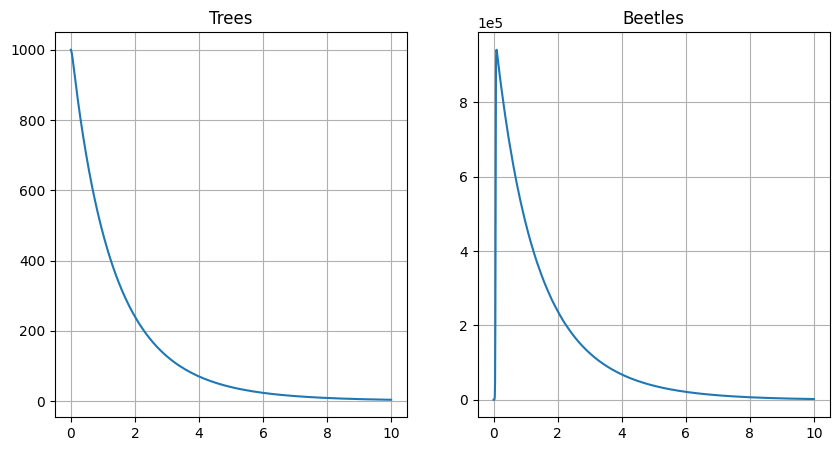

In [52]:
sim_length = 10

t_span = (0, sim_length)
y0 = [k, 5]
sol = solve_ivp(beetle_tree, t_span, y0, max_step=0.1)

# plt.plot(sol.t, sol.y[0], label='Trees')
# plt.plot(sol.t, sol.y[1], label='Beetles')
# plt.legend()
# plt.grid(True)
# plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.plot(sol.t, sol.y[0])
ax1.set_title('Trees')
ax2.plot(sol.t, sol.y[1])
ax2.set_title('Beetles')
ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax1.grid(True)
ax2.grid(True)

plt.show()

# Transregional Spread

Now, we consider an system where beetles suddenly move into or out of the habitat. For the sake of stress testing the code,
suppose 10 beetles are introduced at year 1, and then 100000 of them are killed in each of year 3 and year 5.

In [53]:
beetle_t = [1,3,5]
intro_n = [10,-100000,-100000]

We can compute this by treating it as a piecewise dynamical system.

In [54]:
def simulation(sim_length, X0, Y0, jumps,jump_amount):

    t_last = 0
    y0_last = [X0, Y0]

    t_all = []
    X_all = []
    Y_all = []

    for i in range(len(jumps)):
        t_span = (t_last, jumps[i])
        y0 = y0_last
        sol = solve_ivp(beetle_tree, t_span, y0, max_step=0.1)
        t_all.extend(sol.t)
        X_all.extend(sol.y[0])
        Y_all.extend(sol.y[1])
        t_last = jumps[i]
        y0_last = sol.y[:, -1]

        y0_last[1] += jump_amount[i]
        if y0_last[1] < 0:
            y0_last[1] = 0

    t_span = (t_last, sim_length)
    y0 = y0_last
    sol = solve_ivp(beetle_tree, t_span, y0, max_step=0.1)
    t_all.extend(sol.t)
    X_all.extend(sol.y[0])
    Y_all.extend(sol.y[1])

    return t_all, X_all, Y_all

Running the simulation:

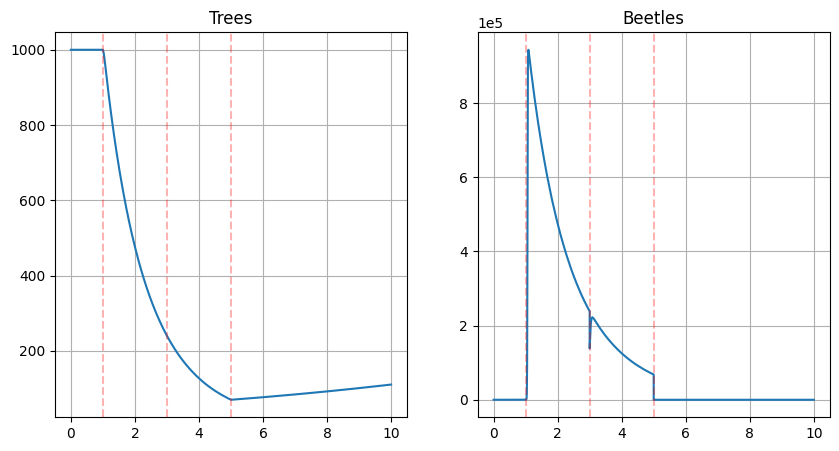

In [55]:
sim_length = 10

t_sim, x_sim, y_sim = simulation(sim_length, k, 0, beetle_t, intro_n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.plot(t_sim, x_sim)
ax1.set_title('Trees')
ax2.plot(t_sim, y_sim)
ax2.set_title('Beetles')

for t in beetle_t:
    ax1.axvline(t, color='red', linestyle='--', alpha=0.3)
    ax2.axvline(t, color='red', linestyle='--', alpha=0.3)

ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax1.grid(True)
ax2.grid(True)
plt.show()

We observe that before the region is infested, the tree population is maintained at 1000. However, as soon as some beetles arrive, their population skyrockets and the trees are quickly killed. This fits with our expectations.